# Task - 1: Table Booking and Online Delivery

## Importing required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.stats as st
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None) 
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.float_format', '{:.3f}'.format) 

sns.set_style("whitegrid")

## Loading Data

In [2]:
base_path = Path.cwd().parents[1]  
file_path = base_path / "Notebooks" / "processed_data" / "Dataset_filtered.csv"
df = pd.read_csv(file_path)

## Initial inspection

In [3]:
df.head(10)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.028,14.565,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.800,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014,14.554,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.500,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.057,14.581,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.400,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056,14.585,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.900,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.058,14.584,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.800,Dark Green,Excellent,229
5,18189371,Din Tai Fung,162,Mandaluyong City,"Ground Floor, Mega Fashion Hall, SM Megamall, ...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056,14.584,Chinese,1000,Botswana Pula(P),No,No,No,No,3,4.400,Green,Very Good,336
6,6300781,Buffet 101,162,Pasay City,"Building K, SM By The Bay, Sunset Boulevard, M...","SM by the Bay, Mall of Asia Complex, Pasay City","SM by the Bay, Mall of Asia Complex, Pasay Cit...",120.980,14.531,"Asian, European",2000,Botswana Pula(P),Yes,No,No,No,4,4.000,Green,Very Good,520
7,6301290,Vikings,162,Pasay City,"Building B, By The Bay, Seaside Boulevard, Mal...","SM by the Bay, Mall of Asia Complex, Pasay City","SM by the Bay, Mall of Asia Complex, Pasay Cit...",120.979,14.540,"Seafood, Filipino, Asian, European",2000,Botswana Pula(P),Yes,No,No,No,4,4.200,Green,Very Good,677
8,6300010,Spiral - Sofitel Philippine Plaza Manila,162,Pasay City,"Plaza Level, Sofitel Philippine Plaza Manila, ...","Sofitel Philippine Plaza Manila, Pasay City","Sofitel Philippine Plaza Manila, Pasay City, P...",120.980,14.553,"European, Asian, Indian",6000,Botswana Pula(P),Yes,No,No,No,4,4.900,Dark Green,Excellent,621
9,6314987,Locavore,162,Pasig City,"Brixton Technology Center, 10 Brixton Street, ...",Kapitolyo,"Kapitolyo, Pasig City",121.057,14.572,Filipino,1100,Botswana Pula(P),Yes,No,No,No,3,4.800,Dark Green,Excellent,532


In [4]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 9542
Number of columns: 21


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9542 entries, 0 to 9541
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9542 non-null   int64  
 1   Restaurant Name       9542 non-null   object 
 2   Country Code          9542 non-null   int64  
 3   City                  9542 non-null   object 
 4   Address               9542 non-null   object 
 5   Locality              9542 non-null   object 
 6   Locality Verbose      9542 non-null   object 
 7   Longitude             9542 non-null   float64
 8   Latitude              9542 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9542 non-null   int64  
 11  Currency              9542 non-null   object 
 12  Has Table booking     9542 non-null   object 
 13  Has Online delivery   9542 non-null   object 
 14  Is delivering now     9542 non-null   object 
 15  Switch to order menu 

In [6]:
# missing value inspection
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [7]:
# duplicate rows inspection
df.duplicated(keep=False).any()

np.False_

In [8]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [9]:
df_1 = df[['Restaurant ID', 'Restaurant Name','Has Table booking','Has Online delivery', 
            'Is delivering now', 'Switch to order menu','Price range', 'Aggregate rating', 'Rating text', 'Votes']]

df_1.head()

,Restaurant ID,Restaurant Name,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating text,Votes
0,6317637,Le Petit Souffle,Yes,No,No,No,3,4.800,Excellent,314
1,6304287,Izakaya Kikufuji,Yes,No,No,No,3,4.500,Excellent,591
2,6300002,Heat - Edsa Shangri-La,Yes,No,No,No,4,4.400,Very Good,270
3,6318506,Ooma,No,No,No,No,4,4.900,Excellent,365
4,6314302,Sambo Kojin,Yes,No,No,No,4,4.800,Excellent,229


In [10]:
mapping = {1:'Budget' ,2:'Mid' ,3:'Premium' ,4:'Luxury'}
df_1['Price range'] = df_1['Price range'].replace(mapping)
df_1.head(10)

,Restaurant ID,Restaurant Name,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating text,Votes
0,6317637,Le Petit Souffle,Yes,No,No,No,Premium,4.800,Excellent,314
1,6304287,Izakaya Kikufuji,Yes,No,No,No,Premium,4.500,Excellent,591
2,6300002,Heat - Edsa Shangri-La,Yes,No,No,No,Luxury,4.400,Very Good,270
3,6318506,Ooma,No,No,No,No,Luxury,4.900,Excellent,365
4,6314302,Sambo Kojin,Yes,No,No,No,Luxury,4.800,Excellent,229
5,18189371,Din Tai Fung,No,No,No,No,Premium,4.400,Very Good,336
6,6300781,Buffet 101,Yes,No,No,No,Luxury,4.000,Very Good,520
7,6301290,Vikings,Yes,No,No,No,Luxury,4.200,Very Good,677
8,6300010,Spiral - Sofitel Philippine Plaza Manila,Yes,No,No,No,Luxury,4.900,Excellent,621
9,6314987,Locavore,Yes,No,No,No,Premium,4.800,Excellent,532


### **Table Booking and Online Delivery**

In [11]:
for col in ['Has Table booking','Has Online delivery']:
    print(f'___________________{col}___________________')
    print(df_1[col].value_counts(normalize=True)*100)
    print('='*40)
    print('\n')

___________________Has Table booking___________________
Has Table booking
No    87.864
Yes   12.136
Name: proportion, dtype: float64


___________________Has Online delivery___________________
Has Online delivery
No    74.314
Yes   25.686
Name: proportion, dtype: float64




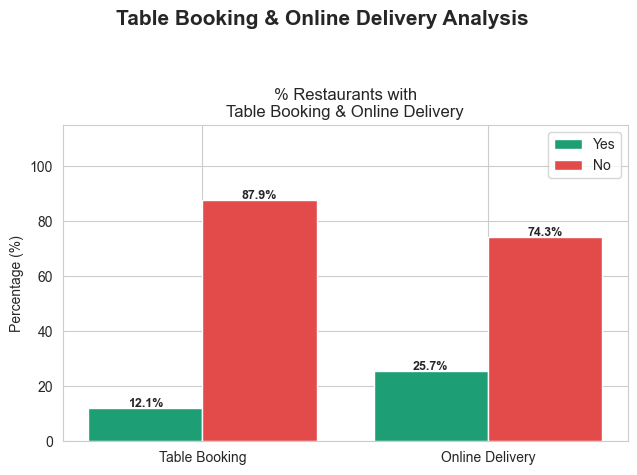

In [12]:
table_pct   = df_1['Has Table booking'].value_counts(normalize=True) * 100
delivery_pct = df_1['Has Online delivery'].value_counts(normalize=True) * 100

categories = ['Table Booking', 'Online Delivery']
yes_vals   = [table_pct.get('Yes', 0), delivery_pct.get('Yes', 0)]
no_vals    = [table_pct.get('No', 0),  delivery_pct.get('No', 0)]

# Create figure and axis
fig, ax = plt.subplots()

fig.suptitle('Table Booking & Online Delivery Analysis', fontsize=15, fontweight='bold')

x = np.arange(len(categories))

ax.bar(x - 0.2, yes_vals, width=0.4, label='Yes', color='#1D9E75', edgecolor='white')
ax.bar(x + 0.2, no_vals,  width=0.4, label='No',  color='#E24B4A', edgecolor='white')

# Labels on bars
for i, (y, n) in enumerate(zip(yes_vals, no_vals)):
    ax.text(i - 0.2, y + 0.5, f'{y:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.text(i + 0.2, n + 0.5, f'{n:.1f}%', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Percentage (%)')
ax.set_title('% Restaurants with\nTable Booking & Online Delivery')
plt.tight_layout(rect=[0, 0, 1, 0.92])
ax.legend()
ax.set_ylim(0, 115)

base_path = Path.cwd().parents[1]
file_path = base_path / "Notebooks" / "reports" / "Table_Booking_Online_Delivery_Analysis.png"
plt.savefig(file_path, dpi=150, bbox_inches='tight')
plt.show()

**Observation:**
- Only ~12% restaurants ***have Table Booking***.
- Only ~26% restaurants ***have Online Delivery***.

### **Average rating with vs without Table Booking**

In [13]:
df_1

,Restaurant ID,Restaurant Name,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating text,Votes
0,6317637,Le Petit Souffle,Yes,No,No,No,Premium,4.800,Excellent,314
1,6304287,Izakaya Kikufuji,Yes,No,No,No,Premium,4.500,Excellent,591
2,6300002,Heat - Edsa Shangri-La,Yes,No,No,No,Luxury,4.400,Very Good,270
3,6318506,Ooma,No,No,No,No,Luxury,4.900,Excellent,365
4,6314302,Sambo Kojin,Yes,No,No,No,Luxury,4.800,Excellent,229
...,...,...,...,...,...,...,...,...,...,...
9537,5915730,Naml۱ Gurme,No,No,No,No,Premium,4.100,Very Good,788
9538,5908749,Ceviz A��ac۱,No,No,No,No,Premium,4.200,Very Good,1034
9539,5915807,Huqqa,No,No,No,No,Luxury,3.700,Good,661
9540,5916112,A���k Kahve,No,No,No,No,Luxury,4.000,Very Good,901


In [14]:
df_1[['Aggregate rating']].describe()

,Aggregate rating
count,9542.000
mean,2.665
std,1.517
min,0.000
25%,2.500
50%,3.200
75%,3.700
max,4.900


In [15]:
temp = df_1[df_1['Aggregate rating']==0.0][['Aggregate rating', 'Rating text', 'Votes']]
temp

,Aggregate rating,Rating text,Votes
30,0.000,Not rated,2
58,0.000,Not rated,1
69,0.000,Not rated,0
77,0.000,Not rated,2
78,0.000,Not rated,2
...,...,...,...
9100,0.000,Not rated,1
9101,0.000,Not rated,3
9102,0.000,Not rated,0
9103,0.000,Not rated,1


In [16]:
print(temp['Rating text'].value_counts())
print()
print(temp['Votes'].value_counts())

Rating text
Not rated    2148
Name: count, dtype: int64

Votes
0    1094
1     483
2     327
3     244
Name: count, dtype: int64


**Note:**
- From previous analysis, we have seen that
   * Exactly 2,148 restaurants (22.5%) have a rating of 0.0, and the Rating text column labels them "Not rated" — these are definitely missing values, not true zero ratings.
   * Crucially, 1,054 out of 2148 of these "Not rated" entries actually have non-zero votes, meaning some users voted but the platform never computed an aggregate. This makes them a distinct data quality issue.
- For further analysis, we are ignoring those restaurants which have a aggregate rating of 0.0

In [17]:
# Average rating of restaurants with vs without table booking

rated = df_1[df_1['Aggregate rating'] > 0]
booking_rating = rated.groupby('Has Table booking')[['Aggregate rating']].mean()
booking_rating

,Aggregate rating
Has Table booking,
No,3.413
Yes,3.588


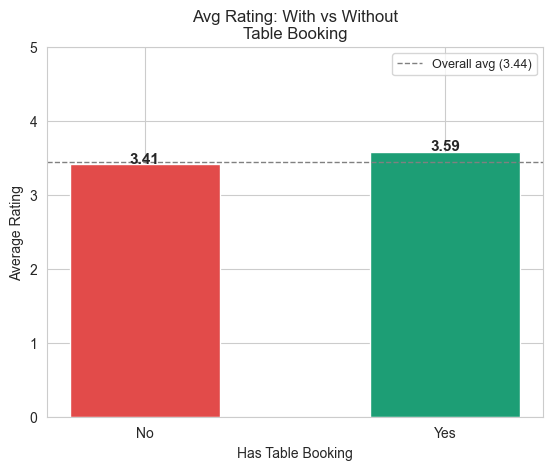

In [18]:
rated = df_1[df_1['Aggregate rating'] > 0]
booking_rating = rated.groupby('Has Table booking')['Aggregate rating'].mean()

fig, ax = plt.subplots()
colors = ['#1D9E75' if i == 'Yes' else '#E24B4A' for i in booking_rating.index]
bars = ax.bar(booking_rating.index, booking_rating.values,
                   color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, booking_rating.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Has Table Booking')
ax.set_ylabel('Average Rating')
ax.set_title('Avg Rating: With vs Without\nTable Booking')
ax.set_ylim(0, 5)
ax.axhline(y=rated['Aggregate rating'].mean(), color='gray', linestyle='--',
                linewidth=1, label=f"Overall avg ({rated['Aggregate rating'].mean():.2f})")
ax.legend(fontsize=9)

base_path = Path.cwd().parents[1]
file_path = base_path / "Notebooks" / "reports" / "Avg_Rating_With_vs_Without_Table_Booking.png"
plt.savefig(file_path, dpi=150, bbox_inches='tight')
plt.show()

**Observation:**
- The average rating is slightly higher for those restaurants which ***have table booking facility***.

### **Online Delivery and Price Range**

In [19]:
df_1['Price range'].value_counts()

Price range
Budget     4438
Mid        3113
Premium    1405
Luxury      586
Name: count, dtype: int64

In [20]:
cats = list(df_1['Price range'].value_counts().index)
cats

['Budget', 'Mid', 'Premium', 'Luxury']

In [21]:
for cat in cats:
    print(f"_______________{cat}_______________")
    print(df_1[df_1['Price range']==cat]['Has Online delivery'].value_counts(normalize=True)*100)
    print("="*35)
    print("\n")

_______________Budget_______________
Has Online delivery
No    84.205
Yes   15.795
Name: proportion, dtype: float64


_______________Mid_______________
Has Online delivery
No    58.689
Yes   41.311
Name: proportion, dtype: float64


_______________Premium_______________
Has Online delivery
No    70.747
Yes   29.253
Name: proportion, dtype: float64


_______________Luxury_______________
Has Online delivery
No    90.956
Yes    9.044
Name: proportion, dtype: float64




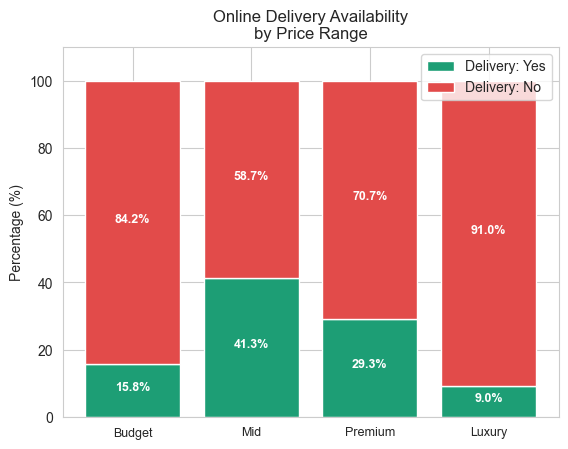

In [22]:
fig, ax = plt.subplots()
price_delivery = (df_1.groupby(['Price range', 'Has Online delivery'])
                    .size()
                    .unstack(fill_value=0))

order = ['Budget', 'Mid', 'Premium', 'Luxury']
price_delivery = price_delivery.reindex(order)
price_delivery_pct = price_delivery.div(price_delivery.sum(axis=1), axis=0) * 100

x = np.arange(len(price_delivery_pct))

ax.bar(x, price_delivery_pct.get('Yes', 0), label='Delivery: Yes',
            color='#1D9E75', edgecolor='white')
ax.bar(x, price_delivery_pct.get('No', 0),  label='Delivery: No',
            color='#E24B4A', edgecolor='white',
            bottom=price_delivery_pct.get('Yes', 0))

for i, (yes_v, no_v) in enumerate(zip(price_delivery_pct.get('Yes', [0]*4),
                                       price_delivery_pct.get('No',  [0]*4))):
    ax.text(i, yes_v / 2,        f'{yes_v:.1f}%', ha='center', fontsize=9,
                 fontweight='bold', color='white')
    ax.text(i, yes_v + no_v / 2, f'{no_v:.1f}%',  ha='center', fontsize=9,
                 fontweight='bold', color='white')

ax.set_xticks(x)
ax.set_xticklabels([i for i in price_delivery_pct.index], fontsize=9)
ax.set_ylabel('Percentage (%)')
ax.set_title('Online Delivery Availability\nby Price Range')
ax.legend()
ax.set_ylim(0, 110)
base_path = Path.cwd().parents[1]
file_path = base_path / "Notebooks" / "reports" / "Online_Delivery_Availability_by_Price_Range.png"
plt.savefig(file_path, dpi=150, bbox_inches='tight')
plt.show()

# Task - 2: Price Range Analysis

In [23]:
df_1.head()

,Restaurant ID,Restaurant Name,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating text,Votes
0,6317637,Le Petit Souffle,Yes,No,No,No,Premium,4.800,Excellent,314
1,6304287,Izakaya Kikufuji,Yes,No,No,No,Premium,4.500,Excellent,591
2,6300002,Heat - Edsa Shangri-La,Yes,No,No,No,Luxury,4.400,Very Good,270
3,6318506,Ooma,No,No,No,No,Luxury,4.900,Excellent,365
4,6314302,Sambo Kojin,Yes,No,No,No,Luxury,4.800,Excellent,229


In [24]:
df_1['Price range'].value_counts(normalize=True)*100

Price range
Budget    46.510
Mid       32.624
Premium   14.724
Luxury     6.141
Name: proportion, dtype: float64

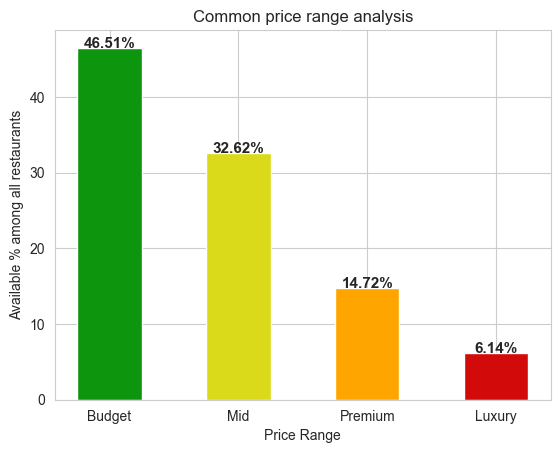

In [25]:
values = list(df_1['Price range'].value_counts(normalize=True).values)
values = [val*100 for val in values]
index = list(df_1['Price range'].value_counts(normalize=True).index)

colors = ["#0D960D", "#DADA1B", "#FFA500", "#D30A0A"]
fig, ax = plt.subplots()

bars = ax.bar(index, values, color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                 f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Price Range')
ax.set_ylabel('Available % among all restaurants')
ax.set_title('Common price range analysis')
base_path = Path.cwd().parents[1]
file_path = base_path / "Notebooks" / "reports" / "Common_price_range_analysis.png"
plt.savefig(file_path, dpi=150, bbox_inches='tight')
plt.show()

**Observation:**
- ***Budget Price Range*** is the most common price range among all the restaurants

In [26]:
# Average rating for each price range

rated = df_1[df_1['Aggregate rating'] > 0]
price_rating = rated.groupby('Price range')[['Aggregate rating']].mean().sort_values(by='Aggregate rating')
price_rating

,Aggregate rating
Price range,
Budget,3.238
Mid,3.377
Premium,3.777
Luxury,3.891


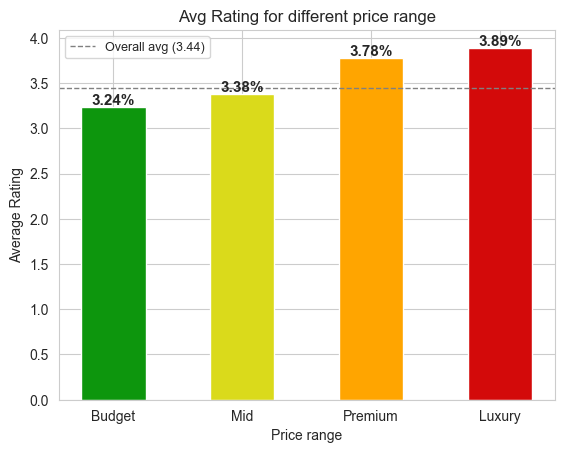

In [27]:
values = [round(val, 2) for val in list(price_rating['Aggregate rating'])]
index = list(price_rating.index)

colors = ["#0D960D", "#DADA1B", "#FFA500", "#D30A0A"]
fig, ax = plt.subplots()

bars = ax.bar(index, values, color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                 f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Price range')
ax.set_ylabel('Average Rating')
ax.set_title('Avg Rating for different price range')

ax.axhline(y=rated['Aggregate rating'].mean(), color='gray', linestyle='--',
                linewidth=1, label=f"Overall avg ({rated['Aggregate rating'].mean():.2f})")
ax.legend(fontsize=9)
base_path = Path.cwd().parents[1]
file_path = base_path / "Notebooks" / "reports" / "Avg_Rating_for_different_price_range.png"
plt.savefig(file_path, dpi=150, bbox_inches='tight')
plt.show()

**Observation:**
- ***Luxury price range*** has better average rating compared to other price ranges

### Identifying the color that represents the highest average rating among different price ranges

In [28]:
cats

['Budget', 'Mid', 'Premium', 'Luxury']

In [29]:
for cat in cats:
    print(f"__________{cat}__________")
    val = df_1[df_1['Price range']==cat]['Aggregate rating'].max()
    print("Maximum rating: {}".format(val))
    color = df[(df_1['Price range']==cat) & (df_1['Aggregate rating']==val)]['Rating color'].unique()[0]
    print("Related rating color: {}".format(color))
    print("="*40)
    print("\n")

__________Budget__________
Maximum rating: 4.9
Related rating color: Dark Green


__________Mid__________
Maximum rating: 4.9
Related rating color: Dark Green


__________Premium__________
Maximum rating: 4.9
Related rating color: Dark Green


__________Luxury__________
Maximum rating: 4.9
Related rating color: Dark Green




**Observation:**
- Every price range has 4.9 as it's maximum rating and the related rating color is ***Dark Green***

# Task - 3: Feature Engineering

In [30]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.028,14.565,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.800,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014,14.554,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.500,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.057,14.581,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.400,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056,14.585,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.900,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.058,14.584,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.800,Dark Green,Excellent,229


In [31]:
# calculating length of restaurant name
df.insert(loc=2, column='Restaurant Name Length', value=df['Restaurant Name'].apply(lambda x: len(x)))

In [32]:
# longest and shortest restaurant name
print(f"Longest restaurant name(s):\n{df[df['Restaurant Name Length']==df['Restaurant Name Length'].max()]['Restaurant Name'].squeeze()}")
print(f"Length: {df['Restaurant Name Length'].max()}")
print()
print(f"Shortest restaurant name(s):\n{df[df['Restaurant Name Length']==df['Restaurant Name Length'].min()]['Restaurant Name'].squeeze()}")
print(f"Length: {df['Restaurant Name Length'].min()}")

Longest restaurant name(s):
Madhuban Restaurant - Welcome Hotel Rama International
Length: 54

Shortest restaurant name(s):
1579    A1
6857    G+
8967    4U
Name: Restaurant Name, dtype: object
Length: 2


In [33]:
# calculating length of address
df.insert(loc=5, column='Address Length', value=df['Address'].apply(lambda x: len(x)))

In [34]:
# longest and shortest address
print(f"Longest address(s):\n{df[df['Address Length']==df['Address Length'].max()]['Address'].squeeze()}")
print(f"Length: {df['Address Length'].max()}")
print()
print(f"Shortest address(s):\n{df[df['Address Length']==df['Address Length'].min()]['Address'].squeeze()}")
print(f"Length: {df['Address Length'].min()}")

Longest address(s):
34, 102B, 109 & 110, Ground/1st Floor, Multilevel Parking Cum Commercial Complex (MLCP), DLF South Square, Sarojini Nagar, New Delhi
Length: 132

Shortest address(s):
Bunglow Road,
Length: 13


In [35]:
df.head()

,Restaurant ID,Restaurant Name,Restaurant Name Length,Country Code,City,Address Length,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,16,162,Makati City,71,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.028,14.565,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.800,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,16,162,Makati City,67,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014,14.554,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.500,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,22,162,Mandaluyong City,56,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.057,14.581,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.400,Green,Very Good,270
3,6318506,Ooma,4,162,Mandaluyong City,70,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056,14.585,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.900,Dark Green,Excellent,365
4,6314302,Sambo Kojin,11,162,Mandaluyong City,64,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.058,14.584,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.800,Dark Green,Excellent,229


In [36]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Restaurant Name Length',
       'Country Code', 'City', 'Address Length', 'Address', 'Locality',
       'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

### Feature Encoding

In [37]:
df.dtypes

Restaurant ID               int64
Restaurant Name            object
Restaurant Name Length      int64
Country Code                int64
City                       object
Address Length              int64
Address                    object
Locality                   object
Locality Verbose           object
Longitude                 float64
Latitude                  float64
Cuisines                   object
Average Cost for two        int64
Currency                   object
Has Table booking          object
Has Online delivery        object
Is delivering now          object
Switch to order menu       object
Price range                 int64
Aggregate rating          float64
Rating color               object
Rating text                object
Votes                       int64
dtype: object

In [38]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Restaurant Name Length',
       'Country Code', 'City', 'Address Length', 'Address', 'Locality',
       'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [39]:
df_2 = df.drop(labels=['Restaurant Name','Address', 'Locality',
       'Locality Verbose','Switch to order menu'],axis=1)
df_2

,Restaurant ID,Restaurant Name Length,Country Code,City,Address Length,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,16,162,Makati City,71,121.028,14.565,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,3,4.800,Dark Green,Excellent,314
1,6304287,16,162,Makati City,67,121.014,14.554,Japanese,1200,Botswana Pula(P),Yes,No,No,3,4.500,Dark Green,Excellent,591
2,6300002,22,162,Mandaluyong City,56,121.057,14.581,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,4,4.400,Green,Very Good,270
3,6318506,4,162,Mandaluyong City,70,121.056,14.585,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,4,4.900,Dark Green,Excellent,365
4,6314302,11,162,Mandaluyong City,64,121.058,14.584,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,4,4.800,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9537,5915730,11,208,��stanbul,103,28.977,41.023,Turkish,80,Turkish Lira(TL),No,No,No,3,4.100,Green,Very Good,788
9538,5908749,12,208,��stanbul,77,29.041,41.010,"World Cuisine, Patisserie, Cafe",105,Turkish Lira(TL),No,No,No,3,4.200,Green,Very Good,1034
9539,5915807,5,208,��stanbul,73,29.035,41.056,"Italian, World Cuisine",170,Turkish Lira(TL),No,No,No,4,3.700,Yellow,Good,661
9540,5916112,11,208,��stanbul,75,29.036,41.058,Restaurant Cafe,120,Turkish Lira(TL),No,No,No,4,4.000,Green,Very Good,901


In [40]:
num_cols = [col for col in df_2.columns if df[col].dtypes!='str']
cat_cols = [col for col in df_2.columns if col not in num_cols]
print(num_cols,'\n',cat_cols)

['Restaurant ID', 'Restaurant Name Length', 'Country Code', 'City', 'Address Length', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes'] 
 []


In [41]:
# Binary Encoding
mapping = {'No':0, 'Yes':1}

binary_columns = ['Has Table booking', 'Has Online delivery', 'Is delivering now']

for col in binary_columns:
    df_2[col] = df_2[col].replace(mapping)

df_2.head()

,Restaurant ID,Restaurant Name Length,Country Code,City,Address Length,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,16,162,Makati City,71,121.028,14.565,"French, Japanese, Desserts",1100,Botswana Pula(P),1,0,0,3,4.800,Dark Green,Excellent,314
1,6304287,16,162,Makati City,67,121.014,14.554,Japanese,1200,Botswana Pula(P),1,0,0,3,4.500,Dark Green,Excellent,591
2,6300002,22,162,Mandaluyong City,56,121.057,14.581,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),1,0,0,4,4.400,Green,Very Good,270
3,6318506,4,162,Mandaluyong City,70,121.056,14.585,"Japanese, Sushi",1500,Botswana Pula(P),0,0,0,4,4.900,Dark Green,Excellent,365
4,6314302,11,162,Mandaluyong City,64,121.058,14.584,"Japanese, Korean",1500,Botswana Pula(P),1,0,0,4,4.800,Dark Green,Excellent,229


In [42]:
# Ordinal Encoding
rating_text_order = ['Not rated', 'Poor', 'Average', 'Good', 'Very Good', 'Excellent']
df_2['Rating text'] = df_2['Rating text'].map({v: i for i, v in enumerate(rating_text_order)})
 
rating_color_order = ['White', 'Red', 'Orange', 'Yellow', 'Green', 'Dark Green']
df_2['Rating color'] = df_2['Rating color'].map({v: i for i, v in enumerate(rating_color_order)})

df_2.head()

,Restaurant ID,Restaurant Name Length,Country Code,City,Address Length,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,16,162,Makati City,71,121.028,14.565,"French, Japanese, Desserts",1100,Botswana Pula(P),1,0,0,3,4.800,5,5,314
1,6304287,16,162,Makati City,67,121.014,14.554,Japanese,1200,Botswana Pula(P),1,0,0,3,4.500,5,5,591
2,6300002,22,162,Mandaluyong City,56,121.057,14.581,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),1,0,0,4,4.400,4,4,270
3,6318506,4,162,Mandaluyong City,70,121.056,14.585,"Japanese, Sushi",1500,Botswana Pula(P),0,0,0,4,4.900,5,5,365
4,6314302,11,162,Mandaluyong City,64,121.058,14.584,"Japanese, Korean",1500,Botswana Pula(P),1,0,0,4,4.800,5,5,229


In [43]:
# Label Encoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_2['Currency'] = le.fit_transform(df_2['Currency'])
df_2['City']     = le.fit_transform(df_2['City'])

df_2.head()

,Restaurant ID,Restaurant Name Length,Country Code,City,Address Length,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,16,162,73,71,121.028,14.565,"French, Japanese, Desserts",1100,0,1,0,0,3,4.800,5,5,314
1,6304287,16,162,73,67,121.014,14.554,Japanese,1200,0,1,0,0,3,4.500,5,5,591
2,6300002,22,162,75,56,121.057,14.581,"Seafood, Asian, Filipino, Indian",4000,0,1,0,0,4,4.400,4,4,270
3,6318506,4,162,75,70,121.056,14.585,"Japanese, Sushi",1500,0,0,0,0,4,4.900,5,5,365
4,6314302,11,162,75,64,121.058,14.584,"Japanese, Korean",1500,0,1,0,0,4,4.800,5,5,229


In [44]:
# Multi Label Binarizer
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
cuisines_split  = df['Cuisines'].str.split(', ')
cuisine_matrix  = mlb.fit_transform(cuisines_split)
cuisine_df      = pd.DataFrame(cuisine_matrix,
                               columns=[f'Cuisine_{c}' for c in mlb.classes_])
print(f"Cuisine size: {cuisine_df.shape}")
cuisine_df.head()

Cuisine size: (9542, 145)


,Cuisine_Afghani,Cuisine_African,Cuisine_American,Cuisine_Andhra,Cuisine_Arabian,Cuisine_Argentine,Cuisine_Armenian,Cuisine_Asian,Cuisine_Asian Fusion,Cuisine_Assamese,Cuisine_Australian,Cuisine_Awadhi,Cuisine_BBQ,Cuisine_Bakery,Cuisine_Bar Food,Cuisine_Belgian,Cuisine_Bengali,Cuisine_Beverages,Cuisine_Bihari,Cuisine_Biryani,Cuisine_Brazilian,Cuisine_Breakfast,Cuisine_British,Cuisine_Bubble Tea,Cuisine_Burger,Cuisine_Burmese,Cuisine_B�_rek,Cuisine_Cafe,Cuisine_Cajun,Cuisine_Canadian,Cuisine_Cantonese,Cuisine_Caribbean,Cuisine_Charcoal Grill,Cuisine_Chettinad,Cuisine_Chinese,Cuisine_Coffee and Tea,Cuisine_Contemporary,Cuisine_Continental,Cuisine_Cuban,Cuisine_Cuisine Varies,Cuisine_Curry,Cuisine_Deli,Cuisine_Desserts,Cuisine_Dim Sum,Cuisine_Diner,Cuisine_Drinks Only,Cuisine_Durban,Cuisine_D�_ner,Cuisine_European,Cuisine_Fast Food,Cuisine_Filipino,Cuisine_Finger Food,Cuisine_Fish and Chips,Cuisine_French,Cuisine_Fusion,Cuisine_German,Cuisine_Goan,Cuisine_Gourmet Fast Food,Cuisine_Greek,Cuisine_Grill,Cuisine_Gujarati,Cuisine_Hawaiian,Cuisine_Healthy Food,Cuisine_Hyderabadi,Cuisine_Ice Cream,Cuisine_Indian,Cuisine_Indonesian,Cuisine_International,Cuisine_Iranian,Cuisine_Irish,Cuisine_Italian,Cuisine_Izgara,Cuisine_Japanese,Cuisine_Juices,Cuisine_Kashmiri,Cuisine_Kebab,Cuisine_Kerala,Cuisine_Kiwi,Cuisine_Korean,Cuisine_Latin American,Cuisine_Lebanese,Cuisine_Lucknowi,Cuisine_Maharashtrian,Cuisine_Malay,Cuisine_Malaysian,Cuisine_Malwani,Cuisine_Mangalorean,Cuisine_Mediterranean,Cuisine_Mexican,Cuisine_Middle Eastern,Cuisine_Mineira,Cuisine_Mithai,Cuisine_Modern Australian,Cuisine_Modern Indian,Cuisine_Moroccan,Cuisine_Mughlai,Cuisine_Naga,Cuisine_Nepalese,Cuisine_New American,Cuisine_North Eastern,Cuisine_North Indian,Cuisine_Oriya,Cuisine_Pakistani,Cuisine_Parsi,Cuisine_Patisserie,Cuisine_Peranakan,Cuisine_Persian,Cuisine_Peruvian,Cuisine_Pizza,Cuisine_Portuguese,Cuisine_Pub Food,Cuisine_Rajasthani,Cuisine_Ramen,Cuisine_Raw Meats,Cuisine_Restaurant Cafe,Cuisine_Salad,Cuisine_Sandwich,Cuisine_Scottish,Cuisine_Seafood,Cuisine_Singaporean,Cuisine_Soul Food,Cuisine_South African,Cuisine_South American,Cuisine_South Indian,Cuisine_Southern,Cuisine_Southwestern,Cuisine_Spanish,Cuisine_Sri Lankan,Cuisine_Steak,Cuisine_Street Food,Cuisine_Sunda,Cuisine_Sushi,Cuisine_Taiwanese,Cuisine_Tapas,Cuisine_Tea,Cuisine_Teriyaki,Cuisine_Tex-Mex,Cuisine_Thai,Cuisine_Tibetan,Cuisine_Turkish,Cuisine_Turkish Pizza,Cuisine_Vegetarian,Cuisine_Vietnamese,Cuisine_Western,Cuisine_World Cuisine
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [45]:
df_2 = df_2.drop('Cuisines', axis=1)

df_2 = pd.concat([df_2, cuisine_df], axis=1)

df_2.head()

,Restaurant ID,Restaurant Name Length,Country Code,City,Address Length,Longitude,Latitude,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Rating color,Rating text,Votes,Cuisine_Afghani,Cuisine_African,Cuisine_American,Cuisine_Andhra,Cuisine_Arabian,Cuisine_Argentine,Cuisine_Armenian,Cuisine_Asian,Cuisine_Asian Fusion,Cuisine_Assamese,Cuisine_Australian,Cuisine_Awadhi,Cuisine_BBQ,Cuisine_Bakery,Cuisine_Bar Food,Cuisine_Belgian,Cuisine_Bengali,Cuisine_Beverages,Cuisine_Bihari,Cuisine_Biryani,Cuisine_Brazilian,Cuisine_Breakfast,Cuisine_British,Cuisine_Bubble Tea,Cuisine_Burger,Cuisine_Burmese,Cuisine_B�_rek,Cuisine_Cafe,Cuisine_Cajun,Cuisine_Canadian,Cuisine_Cantonese,Cuisine_Caribbean,Cuisine_Charcoal Grill,Cuisine_Chettinad,Cuisine_Chinese,Cuisine_Coffee and Tea,Cuisine_Contemporary,Cuisine_Continental,Cuisine_Cuban,Cuisine_Cuisine Varies,Cuisine_Curry,Cuisine_Deli,Cuisine_Desserts,Cuisine_Dim Sum,Cuisine_Diner,Cuisine_Drinks Only,Cuisine_Durban,Cuisine_D�_ner,Cuisine_European,Cuisine_Fast Food,Cuisine_Filipino,Cuisine_Finger Food,Cuisine_Fish and Chips,Cuisine_French,Cuisine_Fusion,Cuisine_German,Cuisine_Goan,Cuisine_Gourmet Fast Food,Cuisine_Greek,Cuisine_Grill,Cuisine_Gujarati,Cuisine_Hawaiian,Cuisine_Healthy Food,Cuisine_Hyderabadi,Cuisine_Ice Cream,Cuisine_Indian,Cuisine_Indonesian,Cuisine_International,Cuisine_Iranian,Cuisine_Irish,Cuisine_Italian,Cuisine_Izgara,Cuisine_Japanese,Cuisine_Juices,Cuisine_Kashmiri,Cuisine_Kebab,Cuisine_Kerala,Cuisine_Kiwi,Cuisine_Korean,Cuisine_Latin American,Cuisine_Lebanese,Cuisine_Lucknowi,Cuisine_Maharashtrian,Cuisine_Malay,Cuisine_Malaysian,Cuisine_Malwani,Cuisine_Mangalorean,Cuisine_Mediterranean,Cuisine_Mexican,Cuisine_Middle Eastern,Cuisine_Mineira,Cuisine_Mithai,Cuisine_Modern Australian,Cuisine_Modern Indian,Cuisine_Moroccan,Cuisine_Mughlai,Cuisine_Naga,Cuisine_Nepalese,Cuisine_New American,Cuisine_North Eastern,Cuisine_North Indian,Cuisine_Oriya,Cuisine_Pakistani,Cuisine_Parsi,Cuisine_Patisserie,Cuisine_Peranakan,Cuisine_Persian,Cuisine_Peruvian,Cuisine_Pizza,Cuisine_Portuguese,Cuisine_Pub Food,Cuisine_Rajasthani,Cuisine_Ramen,Cuisine_Raw Meats,Cuisine_Restaurant Cafe,Cuisine_Salad,Cuisine_Sandwich,Cuisine_Scottish,Cuisine_Seafood,Cuisine_Singaporean,Cuisine_Soul Food,Cuisine_South African,Cuisine_South American,Cuisine_South Indian,Cuisine_Southern,Cuisine_Southwestern,Cuisine_Spanish,Cuisine_Sri Lankan,Cuisine_Steak,Cuisine_Street Food,Cuisine_Sunda,Cuisine_Sushi,Cuisine_Taiwanese,Cuisine_Tapas,Cuisine_Tea,Cuisine_Teriyaki,Cuisine_Tex-Mex,Cuisine_Thai,Cuisine_Tibetan,Cuisine_Turkish,Cuisine_Turkish Pizza,Cuisine_Vegetarian,Cuisine_Vietnamese,Cuisine_Western,Cuisine_World Cuisine
0,6317637,16,162,73,71,121.028,14.565,1100,0,1,0,0,3,4.800,5,5,314,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,6304287,16,162,73,67,121.014,14.554,1200,0,1,0,0,3,4.500,5,5,591,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,6300002,22,162,75,56,121.057,14.581,4000,0,1,0,0,4,4.400,4,4,270,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,6318506,4,162,75,70,121.056,14.585,1500,0,0,0,0,4,4.900,5,5,365,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,